# Library Import

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

np.random.seed(42)

# DataFrame Creation

In [100]:
# Tabela de obras
obras = pd.DataFrame({
    "obra_id": [1, 2, 3, 4, 5],
    "nome_obra": ["Torre A", "Torre B", "Torre C", "Torre D", "Torre E"],
    "pavimentos": [5, 6, 7, 4, 8],
    "status": ["ativa"] * 5,
    "fase_inicial": ["Acelerada"] * 5
})
# Timeline
datas = pd.date_range(start="2025-01-01", periods=90)

# Baseline
fator = 8 # m³ de agua por pavimento por dia
obras["consumo_base_m3"] = obras["pavimentos"] * fator

obras

,obra_id,nome_obra,pavimentos,status,fase_inicial,consumo_base_m3
0,1,Torre A,5,ativa,Acelerada,40
1,2,Torre B,6,ativa,Acelerada,48
2,3,Torre C,7,ativa,Acelerada,56
3,4,Torre D,4,ativa,Acelerada,32
4,5,Torre E,8,ativa,Acelerada,64


# Water Consumption Model

In [101]:
def nome_fase(dia):
    if dia <= 30:
        return "Acelerada"
    elif dia <= 60:
        return "Intermediária"
    else:
        return "Redução"

def fator_fase(fase):
    fatores = {
        "Acelerada": 1.2,
        "Intermediária": 1.0,
        "Redução": 0.85
    }
    return fatores[fase]

registros = []

for _, obra in obras.iterrows():
    
    base = obra["consumo_base_m3"]
    torre = obra["nome_obra"]
    ruido_anterior = 1
    
    for i, data in enumerate(datas, start=1):
        
        n_fase = nome_fase(i)
        fator = fator_fase(n_fase)

        # Noise creation
        erro = np.random.normal(0, 0.03)
        ruido = 0.6 * (ruido_anterior - 1) + erro + 1
        consumo_dia = base * fator * ruido

        # Leak_1 — Torre D
        if torre == 'Torre D' and 5 <= i <= 35:
            consumo_dia *= 1 + 0.01 * (i - 10)
        
        # Leak_2 — Torre E
        if torre == 'Torre E' and i >= 40:
            t = i - 40
            if t < 10:
                consumo_dia *= 1 + 0.002 * t
            else:
                consumo_dia *= 1 + 0.08 / (1 + np.exp(-0.4 * (t - 10)))
                
        ruido_anterior = ruido
        
        registros.append({
            "dia_obra": i,
            "data": data,
            "obra_id": obra["obra_id"],
            "nome_obra": obra["nome_obra"],
            "fase": n_fase,
            "consumo_m3": consumo_dia
        })

consumo_agua = pd.DataFrame(registros)

consumo_agua.tail()

,dia_obra,data,obra_id,nome_obra,fase,consumo_m3
445,86,2025-03-27,5,Torre E,Redução,57.662143
446,87,2025-03-28,5,Torre E,Redução,58.744237
447,88,2025-03-29,5,Torre E,Redução,57.090748
448,89,2025-03-30,5,Torre E,Redução,56.849527
449,90,2025-03-31,5,Torre E,Redução,55.743589


# Auxiliary Functions

In [102]:
def filtrar_obra(df, nome):
    if nome not in df["nome_obra"].unique():
        raise ValueError("Obra não encontrada")
    return df[df["nome_obra"] == nome].copy()

def filtrar_fase(df, fase):
    if fase not in df["fase"].unique():
        raise ValueError("Fase não encontrada.")
    return df[df["fase"] == fase].copy()

# Exploratory Data Analysis (EDA)

## DF Overview

In [103]:
consumo_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dia_obra    450 non-null    int64         
 1   data        450 non-null    datetime64[ns]
 2   obra_id     450 non-null    int64         
 3   nome_obra   450 non-null    object        
 4   fase        450 non-null    object        
 5   consumo_m3  450 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 21.2+ KB


In [104]:
consumo_agua.describe()

,dia_obra,data,obra_id,consumo_m3
count,450.000000,450,450.000000,450.000000
mean,45.500000,2025-02-14 11:59:59.999999744,3.000000,49.528816
min,1.000000,2025-01-01 00:00:00,1.000000,25.272020
25%,23.000000,2025-01-23 00:00:00,2.000000,39.625474
50%,45.500000,2025-02-14 12:00:00,3.000000,47.436311
75%,68.000000,2025-03-09 00:00:00,4.000000,59.358806
max,90.000000,2025-03-31 00:00:00,5.000000,84.435973
std,26.008072,NaN,1.415788,13.924633


## Temporal Series

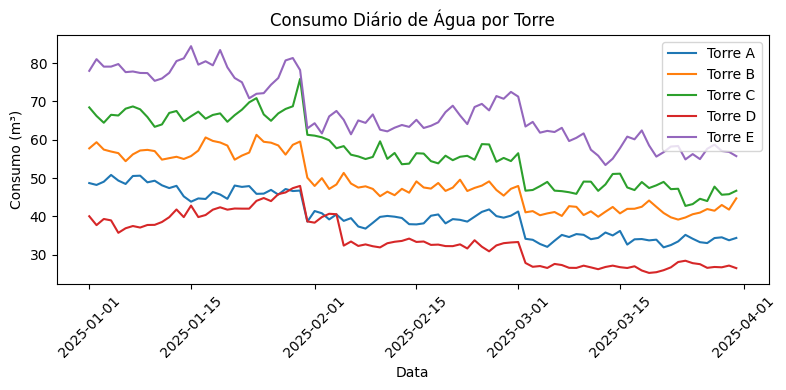

In [105]:
plt.figure(figsize=(8,4))

for nome_obra, df_obra in consumo_agua.groupby("nome_obra"):
    plt.plot(df_obra["data"], df_obra["consumo_m3"], label=nome_obra)

plt.title("Consumo Diário de Água por Torre")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Torre D apresenta comportamento anômalo crescente após 2025-01-15.

## Tower Comparison

### BoxPlot

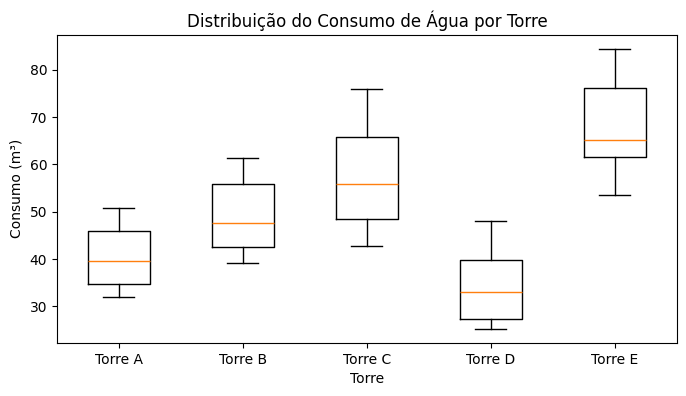

In [106]:
dados_boxplot = [
    df["consumo_m3"].values
    for _, df in consumo_agua.groupby("nome_obra")
]

labels = consumo_agua["nome_obra"].unique()

plt.figure(figsize=(8,4))
plt.boxplot(dados_boxplot, labels=labels)
plt.title("Distribuição do Consumo de Água por Torre")
plt.xlabel("Torre")
plt.ylabel("Consumo (m³)")
plt.show()

Torre D<br>

assimetria positiva (right-skew)<br>

compressão de variância

deslocamento do nível médio

comportamento fora do esperado dado o tamanho<br>

Torre E<br>

assimetria positiva (right-skew)<br>

eventos extremos superiores<br>

variabilidade tardia<br>

### Average Consumption by Tower

In [107]:
media = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .mean()
    .sort_values()
    .to_frame("Average Consumption (m³)")
)

display(media)

,Average Consumption (m³)
nome_obra,
Torre D,33.977430
Torre A,40.324215
Torre B,48.870473
Torre C,56.929422
Torre E,67.542538


### Standard Deviation by Tower

In [108]:
std = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .std()
    .sort_values()
    .to_frame("Standard Deviation (m³)")
)

display(std)

,Standard Deviation (m³)
nome_obra,
Torre A,5.677112
Torre D,6.354603
Torre B,6.774264
Torre C,8.477597
Torre E,8.580100


O desvio padrão da Torre D, apesar da menor quantidade de pavimentos, sugere comportamento atípico do consumo ao longo do tempo.<br>

## Tower D Anomaly Evaluation

### Temporal Series

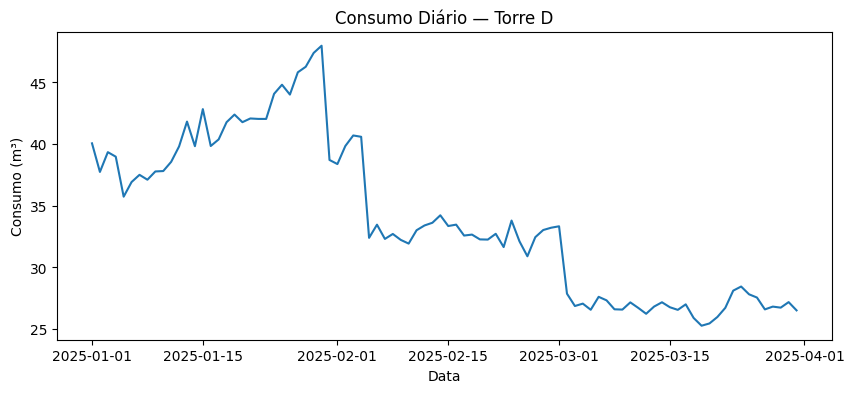

In [109]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

plt.figure(figsize=(10,4))
plt.plot(torre_d["data"], torre_d["consumo_m3"])
plt.title("Consumo Diário — Torre D")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.show()

### Tower D vs Others Comparison

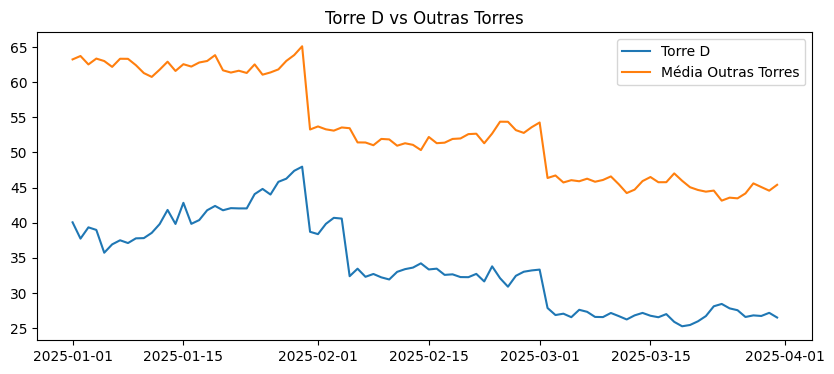

In [110]:
media_por_data = consumo_agua.groupby(["data","nome_obra"])["consumo_m3"].mean().unstack()

plt.figure(figsize=(10,4))
plt.plot(media_por_data.index, media_por_data["Torre D"], label="Torre D")

outras = media_por_data.drop(columns="Torre D").mean(axis=1)
plt.plot(media_por_data.index, outras, label="Média Outras Torres")

plt.legend()
plt.title("Torre D vs Outras Torres")
plt.show()

Observa-se que o perfil de consumo na Torre D nas etapas iniciais diverge daquele observado na média das demais.

## Linear Regression

In [111]:
torre_d = torre_d.reset_index(drop=True)

X = pd.Series(range(len(torre_d["consumo_m3"])))
Y = torre_d["consumo_m3"]

# Adicionando o intercepto
X = sm.add_constant(X)

# Criando e ajustando o modelo
model_rlint = sm.OLS(Y, X)
results_rlint = model_rlint.fit()

# Exibindo o sumário do modelo
print(results_rlint.summary())

                            OLS Regression Results                            
Dep. Variable:             consumo_m3   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     228.9
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.26e-26
Time:                        15:23:23   Log-Likelihood:                -235.97
No. Observations:                  90   AIC:                             475.9
Df Residuals:                      88   BIC:                             480.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.1769      0.704     61.325      0.0

# Regressão Linear Global — Avaliação Inicial

A regressão linear simples foi ajustada considerando todo o período de 90 dias, com o objetivo de avaliar a presença de tendência média no consumo de água da Torre D.

## Resultados Principais

- **R² ≈ 0.72**
- **Coeficiente temporal estatisticamente significativo (p < 0.001)**
- **Durbin-Watson ≈ 0.28**
- Testes de normalidade indicam desvios relevantes nos resíduos

## Interpretação

Embora o modelo apresente bom ajuste estatístico aparente (R² elevado), a estatística de Durbin-Watson revela forte autocorrelação positiva nos resíduos, indicando violação do pressuposto de independência dos erros.

Isso sugere que o processo possui dependência temporal significativa — característica típica de séries temporais operacionais.

Portanto:

- O modelo linear captura tendência média.
- Contudo, não modela explicitamente a estrutura dinâmica do processo.
- Mudanças estruturais internas podem ser diluídas ao longo do período.

Em contextos de monitoramento operacional, essa limitação pode impedir a detecção precoce de eventos progressivos.

## Phase Analisys

In [113]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

fases = ["Acelerada", "Intermediária", "Redução"]

for fase in fases:
    
    df_fase = filtrar_fase(torre_d, fase).reset_index(drop=True)
    
    X = pd.Series(range(len(df_fase)), name="tempo")
    X = sm.add_constant(X)
    Y = df_fase["consumo_m3"]
    
    results = sm.OLS(Y, X).fit()
    
    coef = results.params.iloc[1]
    pval = results.pvalues.iloc[1]
    
    print(f"Fase: {fase}")
    print(f"Coeficiente tempo: {coef:.4f}")
    print(f"P-value: {pval:.4f}")
    print("-"*40)

Fase: Acelerada
Coeficiente tempo: 0.3287
P-value: 0.0000
----------------------------------------
Fase: Intermediária
Coeficiente tempo: -0.1941
P-value: 0.0002
----------------------------------------
Fase: Redução
Coeficiente tempo: -0.0028
P-value: 0.8570
----------------------------------------


# Regressão Linear por Fase — Análise de Tendência Segmentada

Para avaliar o comportamento dentro de cada etapa construtiva, a regressão linear foi ajustada separadamente para as três fases:

- Acelerada  
- Intermediária  
- Redução  

## Resultados

- **Fase Acelerada:** tendência positiva significativa  
- **Fase Intermediária:** tendência negativa significativa  
- **Fase de Redução:** ausência de tendência estatisticamente significativa  

## Interpretação

A regressão por fase captura apenas a inclinação média do consumo ao longo de cada intervalo, assumindo homogeneidade temporal dentro da fase.

Entretanto, caso ocorram mudanças estruturais internas — como alterações progressivas no padrão de consumo — o modelo linear tende a estimar uma única tendência média, diluindo comportamentos localizados.

Assim, embora útil para caracterizar tendências gerais, a regressão linear segmentada não é adequada para identificar mudanças de regime ou anomalias progressivas dentro de uma mesma fase.

----

## Conclusão

As análises anteriores indicam que:

- O consumo apresenta dependência temporal significativa.
- Modelos lineares globais ou segmentados capturam apenas tendência média.
- Não há mecanismo explícito para atualização sequencial da evidência.
- Mudanças graduais podem não ser detectadas precocemente.

Em cenários reais de monitoramento, eventos anômalos raramente ocorrem como quebras abruptas perfeitamente alinhadas aos intervalos de análise. Frequentemente, surgem como alterações graduais no comportamento do sistema.

Isso motiva a adoção de uma abordagem que:

- Incorpore dependência temporal,
- Permita atualização contínua da probabilidade de anomalia,
- Diferencie regimes operacionais distintos.

# Investigação Inicial — Variabilidade do Consumo

Como etapa exploratória complementar, foi analisada a variabilidade do consumo diário de água por torre, utilizando o desvio padrão como medida de dispersão.

| Torre | Desvio padrão (m³) |
|-------|--------------------|
| Torre A | 5,68 |
| Torre D | 6,35 |
| Torre B | 6,77 |
| Torre C | 8,48 |
| Torre E | 8,58 |

---

## Interpretação

Observa-se heterogeneidade na variabilidade entre as torres.

A Torre A apresenta a menor dispersão absoluta, enquanto as Torres C e E apresentam os maiores desvios padrão, possivelmente refletindo maior escala estrutural e maior amplitude operacional.

A Torre D apresenta variabilidade intermediária, não se destacando isoladamente por dispersão extrema. 

Entretanto, a análise visual por meio de boxplots indica diferenças no formato da distribuição, incluindo leve assimetria à direita (right skew) e deslocamento gradual do nível de consumo ao longo do tempo.

Esses padrões sugerem que mudanças estruturais podem ocorrer mesmo quando a variabilidade absoluta não é a maior do conjunto.

---

## Limitação da Análise de Variabilidade

Diferenças de desvio padrão isoladamente não constituem evidência conclusiva de anomalia.

A variabilidade pode ser influenciada por múltiplos fatores:

- Escala estrutural da torre
- Fase construtiva predominante
- Ruído operacional
- Tendências temporais graduais

Além disso, eventos progressivos podem alterar o nível médio do processo sem necessariamente produzir aumento expressivo na dispersão agregada.

Assim, medidas estáticas de dispersão não são suficientes para caracterizar mudança de regime.

---

## Motivação para Modelagem Probabilística

Dado que:

- O processo apresenta dependência temporal significativa;
- Modelos lineares capturam apenas tendência média;
- Medidas agregadas de variabilidade não distinguem regimes operacionais;

Adota-se uma abordagem Bayesiana sequencial para avaliar, de forma probabilística, a plausibilidade de que o comportamento observado em determinada torre esteja associado a um regime distinto.

Essa abordagem permite incorporar incerteza, atualizar evidência ao longo do tempo e diferenciar explicitamente entre regimes normal e anômalo.

# Bayesian Inference

## Inferência Bayesiana — Probabilidade de Vazamento em Torre

# Modelagem Bayesiana Sequencial — Detecção de Regime Anômalo

Dado que análises lineares e medidas agregadas de variabilidade mostraram-se insuficientes para identificar mudanças estruturais no consumo, adota-se uma abordagem Bayesiana sequencial para detecção de regime operacional.

O objetivo inicial é aplicar o modelo à Torre D, sem assumir previamente a existência de vazamento, avaliando probabilisticamente a possibilidade de transição entre dois regimes:

1. **Regime Normal**
2. **Regime Anômalo**

---

## Formulação do Problema

Deseja-se estimar, para cada instante de tempo:

$$
P(H_t = \text{anômalo} \mid X_{1:t})
$$

onde:

- $H_t$ representa o regime operacional no tempo $t$;
- $X_{1:t}$ representa o histórico observado até o instante $t$.

A inferência é realizada de forma sequencial, permitindo atualização contínua da probabilidade de mudança de regime à medida que novos dados são observados.

---

## Estrutura do Modelo

O modelo considera duas distribuições distintas:

- Distribuição do regime normal;
- Distribuição do regime anômalo.

A cada novo dado observado, a probabilidade do sistema estar operando sob cada regime é atualizada segundo a regra de Bayes:

$$
P(H_t \mid X_{1:t}) =
\frac{P(X_t \mid H_t)\, P(H_{t-1})}
{P(X_t)}
$$

Essa abordagem permite:

- Incorporar incerteza explícita;
- Atualizar evidência progressivamente;
- Detectar mudanças estruturais como transição probabilística;
- Evitar dependência de quebras abruptas ou testes pontuais.

---

## Objetivo da Aplicação na Torre D

A aplicação inicial do modelo na Torre D tem como finalidade:

- Verificar a capacidade do detector em identificar mudança estrutural;
- Caracterizar estatisticamente o regime anômalo quando identificado;
- Estimar parâmetros associados ao comportamento anormal.

Somente após a identificação do regime anômalo na Torre D, o padrão estatístico observado será utilizado como referência para avaliação de outras torres.

---

## Generalização para Outras Torres

Uma vez caracterizado o regime anômalo na Torre D, deseja-se estimar:

$$
P(H_E = \text{anômalo} \mid X_E)
$$

avaliando se o comportamento observado na Torre E é compatível com o padrão previamente identificado.

Importante ressaltar que não se assume causalidade entre torres, mas sim possível compartilhamento de condições estruturais e operacionais que influenciam o consumo.

## Set up DF excesso

In [125]:
df_vaz = consumo_agua.copy()
# consumo por pavimento por dia
df_vaz["consumo_por_pav"] = (
    df_vaz["consumo_m3"] /
    df_vaz["nome_obra"].map(
        obras.set_index("nome_obra")["pavimentos"]
    )
)

# baseline normal = média das torres sem vazamento
normais = df_vaz[df_vaz["nome_obra"] != "Torre D"]

baseline_norm = (
    normais.groupby("data")["consumo_por_pav"]
    .mean()
    .reset_index(name="baseline_por_pav")
)

# Torre D normalizada
df_d_norm = df_vaz[df_vaz["nome_obra"] == "Torre D"][
    ["data", "consumo_por_pav"]
]

df_excesso_D = df_d_norm.merge(
    baseline_norm,
    on="data"
)

df_excesso_D["excesso"] = (
    df_excesso_D["consumo_por_pav"] -
    df_excesso_D["baseline_por_pav"]
)

excesso_D = df_excesso_D["excesso"].values

# Torre E normalizada
df_e_norm = df_vaz[df_vaz["nome_obra"] == "Torre E"][
    ["data", "consumo_por_pav"]
]

df_excesso_E = df_e_norm.merge(
    baseline_norm,
    on="data"
)

df_excesso_E["excesso"] = (
    df_excesso_E["consumo_por_pav"] -
    df_excesso_E["baseline_por_pav"]
)

excesso_E = df_excesso_E["excesso"].values

# Demais torres - sem suspeitas
excesso_normais = []

for torre in ["Torre A", "Torre B", "Torre C", "Torre E"]:
    
    df_t = df_vaz[df_vaz["nome_obra"] == torre][
        ["data", "consumo_por_pav"]
    ]
    
    df_t = df_t.merge(baseline_norm, on="data")
    
    excesso = (
        df_t["consumo_por_pav"] -
        df_t["baseline_por_pav"]
    )
    
    excesso_normais.extend(excesso.values)

excesso_normais = np.array(excesso_normais)

## Bayes Application

### Early Detection Tool

In [203]:
def rodar_detector_bayes(
    excesso,
    excesso_normais,
    inicio_vaz=None,
    prior_leak=0.1,
    delta=0.5,
    lambda_slope=1.2,
    tau=10,
    gamma=0.8,
    threshold=0.75
):
    """
    Detector Bayesiano Online com dinâmica amortecida.
    """

    # =========================
    # Preparação do Sinal
    # =========================
    
    sigma_norm = excesso_normais.std()

    excesso_suave = pd.Series(excesso).rolling(
        window=3, min_periods=1
    ).mean().values

    slope = np.gradient(excesso_suave)

    x_signal = excesso_suave + lambda_slope * slope
    x_signal = x_signal / sigma_norm

    # =========================
    # Regimes
    # =========================
    
    mu_norm = 0
    sigma_norm_model = 1

    mu_leak = delta
    sigma_leak = 1

    # =========================
    # Dinâmica
    # =========================
    
    Ts = 1
    alpha = np.exp(-Ts / tau)

    posterior = prior_leak
    posteriores = []

    for x in x_signal:

        posterior_pred = alpha * posterior + (1 - alpha) * prior_leak

        p_x_leak = norm.pdf(x, mu_leak, sigma_leak)
        p_x_norm = norm.pdf(x, mu_norm, sigma_norm_model)

        posterior_bayes = (
            p_x_leak * posterior_pred /
            (p_x_leak * posterior_pred +
             p_x_norm * (1 - posterior_pred))
        )

        posterior = posterior_pred + gamma * (posterior_bayes - posterior_pred)
        posterior = np.clip(posterior, 1e-6, 1 - 1e-6)

        posteriores.append(posterior)

    posteriores = np.array(posteriores)

    # =========================
    # Detecção
    # =========================
    
    detected_day = next(
        (i for i, p in enumerate(posteriores) if p >= threshold),
        None
    )

    if inicio_vaz is not None and detected_day is not None:
        lag = detected_day - inicio_vaz
    else:
        lag = None

    return {
        "posterior": posteriores,
        "detected_day": detected_day,
        "lag": lag
    }

### DataViz

In [206]:
def plotar_detector_bayes(
    posterior,
    excesso,
    inicio_vaz=None,
    fim_vaz=None,
    threshold=0.75,
    titulo="Detecção Bayesiana"
):
    """
    Plota resultado do detector Bayesiano.
    """

    posterior = np.array(posterior)
    dias = np.arange(1, len(posterior) + 1)

    # Detectar cruzamento
    detected_idx = next(
        (i for i, p in enumerate(posterior) if p >= threshold),
        None
    )

    detected_day = detected_idx + 1 if detected_idx is not None else None

    lag = (
        detected_day - inicio_vaz
        if inicio_vaz is not None and detected_day is not None
        else None
    )

    fig, ax1 = plt.subplots(figsize=(12,6))

    # --- Probabilidade ---
    ax1.plot(dias, posterior, linewidth=2.5,
             label="Probabilidade Estimada")

    ax1.axhline(threshold, color='red', linestyle='--',
                linewidth=1.5, label="Threshold Operacional")

    # Região real de vazamento
    if inicio_vaz and fim_vaz:
        ax1.axvspan(inicio_vaz, fim_vaz,
                    alpha=0.15,
                    label="Vazamento Real")

    # Fases fixas (opcional)
    ax1.axvline(30, linestyle=':', alpha=0.6)
    ax1.axvline(60, linestyle=':', alpha=0.6)

    # Detecção
    if detected_day:

        ax1.axvline(detected_day, linestyle='--',
                    linewidth=1.5, label="Detecção")

        if lag is not None:

            # Ajuste automático da seta
            y_text = max(0.3, posterior[detected_idx] - 0.2)
            x_text = min(detected_day + 5, len(dias) - 5)

            ax1.annotate(
                f"Lag = {lag} dias",
                xy=(detected_day, threshold),
                xytext=(x_text, y_text),
                arrowprops=dict(arrowstyle="->"),
                fontsize=11
            )

    ax1.set_ylim(0, 1)
    ax1.set_xlim(1, len(dias))
    ax1.set_ylabel("P(Regime Anômalo)", fontsize=12)
    ax1.set_xlabel("Dia da Obra", fontsize=12)
    ax1.set_title(titulo, fontsize=14)

    # --- Consumo no eixo secundário ---
    ax2 = ax1.twinx()

    ax2.plot(dias, excesso,
             alpha=0.35,
             label="Excesso")

    ax2.set_ylabel("Excesso de Consumo", fontsize=12)

    # --- Legenda combinada ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", frameon=False)

    ax1.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

### Torre D

In [205]:
resultado_D = rodar_detector_bayes(
    excesso=excesso_D,
    excesso_normais=excesso_normais,
    inicio_vaz=5
)

posteriores_D = resultado_D["posterior"]
lag_D = resultado_D["lag"]

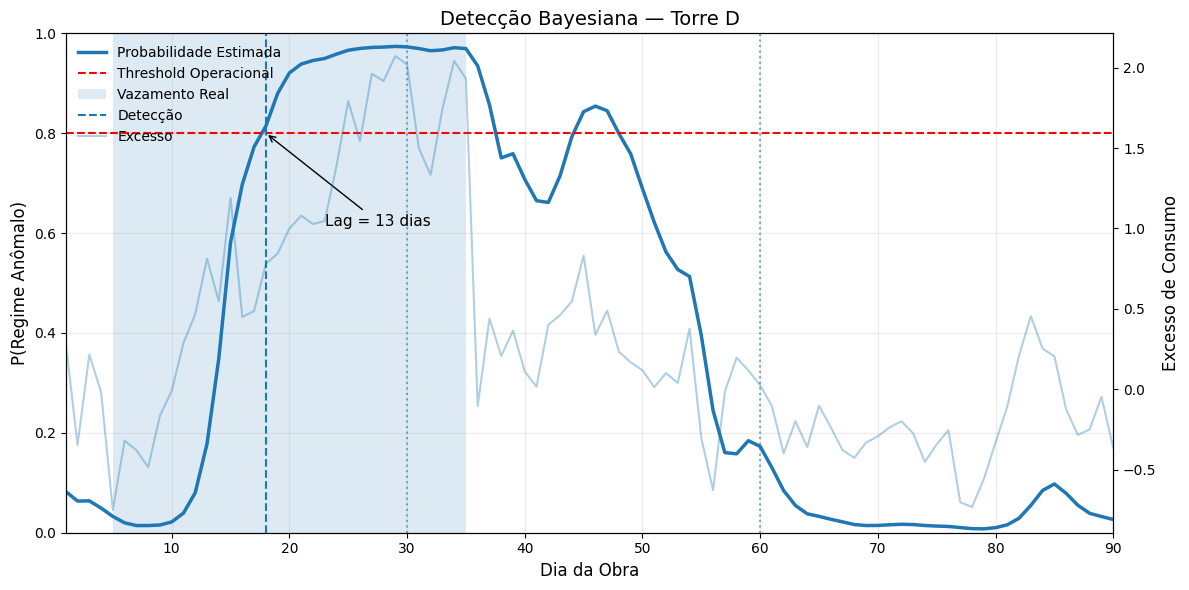

In [212]:
plotar_detector_bayes(
    posterior=posteriores_D,
    excesso=excesso_D,
    inicio_vaz=5,
    fim_vaz=35,
    threshold=0.8,
    titulo="Detecção Bayesiana — Torre D"
)

## Generalização Torre E

In [208]:
resultado_E = rodar_detector_bayes(
    excesso=excesso_E,
    excesso_normais=excesso_normais,
    inicio_vaz=40
)

posteriores_E = resultado_E["posterior"]
lag_E = resultado_E["lag"]

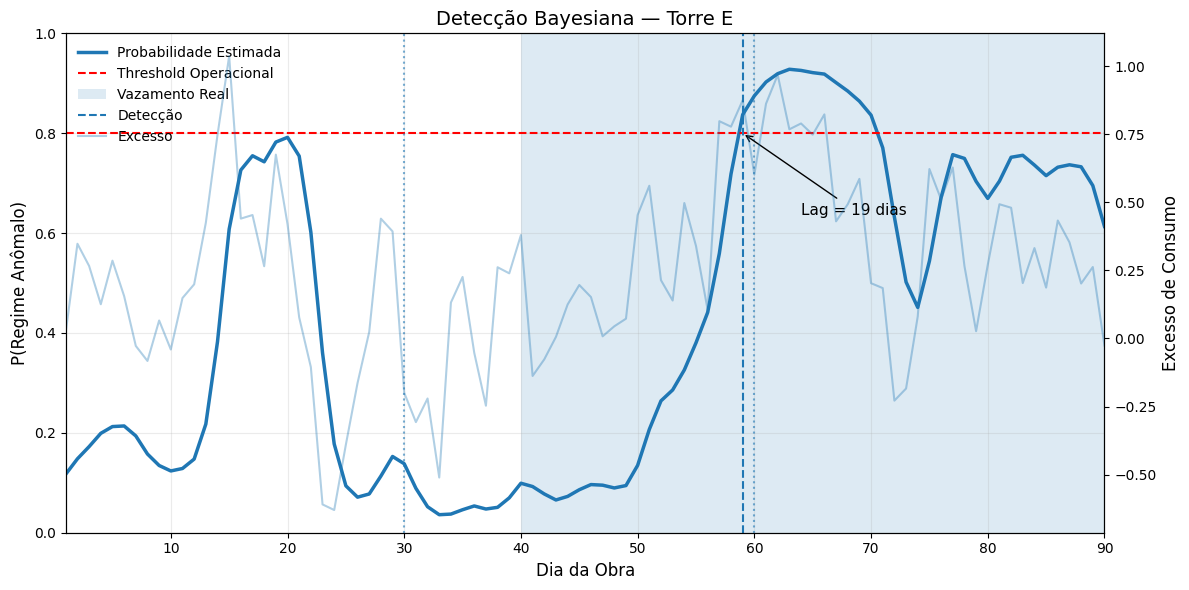

In [211]:
plotar_detector_bayes(
    posterior=posteriores_E,
    excesso=excesso_E,
    inicio_vaz=40,
    fim_vaz=90,
    threshold=0.8,
    titulo="Detecção Bayesiana — Torre E"
)

# Business Impact

In [222]:
def calcular_excesso_detectado(
    df_excesso,
    detected_day,
    nome_torre
):
    """
    Calcula excesso acumulado a partir do dia de detecção.
    """

    if detected_day is None:
        print(f"--- {nome_torre} ---")
        print("Nenhuma detecção realizada.")
        return None, None

    # Ajuste índice (detected_day começa em 1 no gráfico)
    df_periodo = df_excesso.iloc[detected_day-1:].copy()

    excesso_total = df_periodo["excesso"].sum()
    baseline_total = df_periodo["baseline_por_pav"].sum()

    percentual = (excesso_total / baseline_total) * 100

    print(f"--- {nome_torre} ---")
    print(f"Excesso acumulado após detecção: {excesso_total:.2f} m³")
    print(f"Percentual acima do esperado: {percentual:.2f}%")

    return excesso_total, percentual

## Torre D

In [223]:
excesso_D_pos, perc_D_pos = calcular_excesso_detectado(
    df_excesso_D,
    resultado_D["detected_day"] + 1,
    "Torre D"
)

--- Torre D ---
Excesso acumulado após detecção: 25.04 m³
Percentual acima do esperado: 4.29%


## Torre E

In [224]:
excesso_E_pos, perc_E_pos = calcular_excesso_detectado(
    df_excesso_E,
    resultado_E["detected_day"] + 1,
    "Torre E"
)

--- Torre E ---
Excesso acumulado após detecção: 18.06 m³
Percentual acima do esperado: 3.09%


# 🔎 Conclusão — Detecção Bayesiana de Anomalias no Consumo Hídrico

---

## 🎯 Objetivo

Desenvolver um modelo capaz de detectar **mudanças estruturais de regime** no consumo de água de torres em construção, utilizando abordagem probabilística online com atualização sequencial.

---

## 📊 Limitações dos Modelos Tradicionais

A análise exploratória indicou que:

- A regressão linear global não captura adequadamente dependência temporal.
- A regressão faseada identifica tendências médias, mas não é adequada para detecção precoce.
- Medidas estáticas de variabilidade (ex: desvio padrão) não são suficientes para inferir mudança de regime.

Isso motivou a adoção de uma abordagem probabilística dinâmica.

---

## 🧠 Modelo Proposto

Foi implementado um **Detector Bayesiano Online** incorporando:

- Normalização estrutural (m³ por pavimento)
- Combinação de nível + tendência (derivada discreta)
- Atualização sequencial da probabilidade
- Dinâmica amortecida inspirada em teoria de controle
- Limiar operacional ajustável conforme tolerância a risco

A inferência é realizada de forma contínua:

\[
P(H_t = \text{anômalo} \mid X_{1:t})
\]

permitindo atualização da evidência a cada nova observação.

---

## 🏗 Resultados — Torre D

- Identificação de regime anômalo compatível com vazamento progressivo.
- Detecção antecipada em relação à evolução completa da série.
- Quantificação do excesso acumulado após o momento do alerta.
- Estimativa percentual do desvio em relação ao baseline esperado.

O modelo demonstrou capacidade de detectar mudança estrutural mesmo com crescimento gradual.

---

## 🏢 Resultados — Torre E

O maior lag observado em comparação à Torre D é consistente com:

- Menor intensidade do crescimento inicial do vazamento;
- Transição de regime mais suave;
- Maior influência relativa do ruído na fase inicial.

Ainda assim, o modelo demonstrou:

- Estabilidade probabilística;
- Ausência de falso positivo persistente;
- Sensibilidade proporcional à intensidade do sinal.

Embora não caracterizado como vazamento confirmado, o padrão observado justificaria **investigação preventiva** sob perspectiva operacional.

---

## 💼 Implicações Operacionais

A metodologia permite:

- Detectar mudanças graduais em séries temporais operacionais.
- Atualizar evidência em ambiente online.
- Quantificar impacto acumulado após detecção.
- Converter sinal estatístico em decisão técnica.

Mais do que identificar vazamentos, o modelo identifica **mudanças estruturais no comportamento do sistema**.

---

## 🚀 Conclusão Final

A abordagem proposta demonstra que técnicas de inferência Bayesiana sequencial, combinadas com princípios de controle dinâmico, são eficazes para detecção precoce de anomalias progressivas em ambientes operacionais reais.

A metodologia é extensível para:

- Monitoramento de utilidades
- Sistemas industriais
- Sensores IoT
- Processos com mudança gradual de regime

---

**Projeto concluído com foco em robustez estatística, aplicabilidade operacional e interpretabilidade técnica.**